In [5]:
%%writefile requirements.txt
# Cuántico
qiskit
qiskit-machine-learning

# Deep learning (solo notebook 03)
torch
torchvision

# Científico / datos / gráficos
numpy
pandas
matplotlib
pylatexenc

Overwriting requirements.txt


In [6]:
!pip install -r requirements.txt

# E6 · Circuitos de referencia del paper (validación)

**Notebook 02 — reproducción de un subconjunto de los 19 circuitos** de Sim, Johnson & Aspuru-Guzik (2019) para validar la implementación de `qexpr.py` y anclar nuestros resultados contra los hallazgos publicados.

Subconjunto (cubre de baja a alta expresibilidad/entrelazamiento):

| # | Estructura | Nota |
|---|-----------|------|
| 1  | RX, RZ locales | entrelazamiento **nulo** ($Q\approx 0$) |
| 2  | RX, RZ + cadena CNOT | entrelaza pero poco expresivo (pocos parámetros) |
| 9  | H + cadena CZ + RX | entrelaza **mucho** ($Q\to1$) pero **poco expresivo** (solo $n$ parámetros) |
| 13 | RY + anillo CRZ (×2) | expresivo |
| 14 | RY + anillo **CRX** (×2) | expresivo (**CRX > CRZ**) |
| 15 | RY + anillo CNOT (×2) | expresivo |
| 19 | RX, RZ + anillo CRX | expresivo |

**Hallazgos del paper que reproducimos cualitativamente:** el circuito 1 no entrelaza ($Q\approx0$); las secuencias con **CRX** (14) superan a las de **CRZ** (13) en expresibilidad y entrelazamiento; y la expresibilidad depende del número de parámetros (el circuito 9 entrelaza al máximo pero es de los menos expresivos). Los valores exactos dependen del muestreo/profundidad, por lo que validamos el **ranking**, no números concretos.

In [7]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.getcwd())
import qexpr as qx

SEED = 42
N_SAMPLES = 3000
N_BINS = 75
N_QUBITS = 4          # el paper dibuja los circuitos en 4 qubits

OUTPUT_DIR = os.path.abspath(os.path.join('..', '..', 'TFM-EXPERIMENTS', 'outputs'))
TABLES_DIR = os.path.join(OUTPUT_DIR, 'tables')
FIGURES_DIR = os.path.join(OUTPUT_DIR, 'figures')
os.makedirs(TABLES_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
print('Circuitos:', qx.PAPER_SUBSET)

Circuitos: [1, 2, 9, 13, 14, 15, 19]


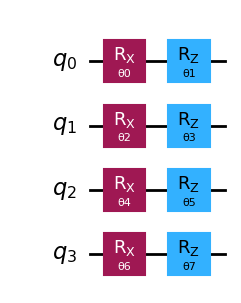

In [8]:
# Dibujo de un par de circuitos para inspección visual
qx.paper_circuit(1, N_QUBITS).draw('mpl')

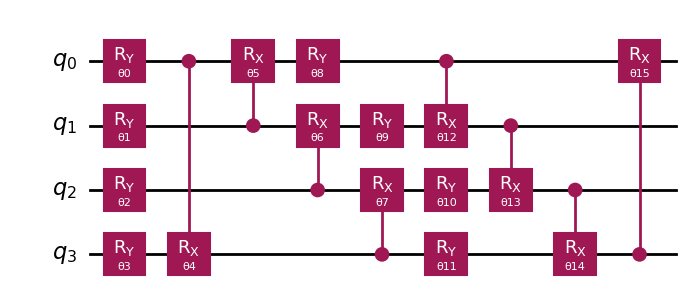

In [9]:
qx.paper_circuit(14, N_QUBITS).draw('mpl')

In [10]:
rows = []
for idx in qx.PAPER_SUBSET:
    qc = qx.paper_circuit(idx, N_QUBITS)
    d = qx.descriptors(qc, N_QUBITS, n_samples=N_SAMPLES, n_bins=N_BINS, seed=SEED)
    d['circuit'] = f'Circuit {idx}'
    d['idx'] = idx
    rows.append(d)
    print(f"Circuit {idx:2d}:  KL={d['expressibility_kl']:.3f}  Q={d['entangling_Q']:.3f}  "
          f"(n_params={d['n_params']}, depth={d['depth']})")

dfp = pd.DataFrame(rows)[['circuit', 'idx', 'n_params', 'depth',
                          'expressibility_kl', 'entangling_Q', 'entangling_Q_std']]
dfp = dfp.sort_values('expressibility_kl').reset_index(drop=True)
dfp.to_csv(os.path.join(TABLES_DIR, 'E6_paper_reference.csv'), index=False)
dfp

Circuit  1:  KL=0.311  Q=-0.000  (n_params=8, depth=2)
Circuit  2:  KL=0.311  Q=0.625  (n_params=8, depth=5)
Circuit  9:  KL=0.685  Q=1.000  (n_params=4, depth=9)
Circuit 13:  KL=0.059  Q=0.407  (n_params=16, depth=28)
Circuit 14:  KL=0.026  Q=0.547  (n_params=16, depth=37)
Circuit 15:  KL=0.187  Q=0.695  (n_params=8, depth=10)
Circuit 19:  KL=0.082  Q=0.417  (n_params=12, depth=23)


,circuit,idx,n_params,depth,expressibility_kl,entangling_Q,entangling_Q_std
0,Circuit 14,14,16,37,0.026054,5.474093e-01,1.896300e-01
1,Circuit 13,13,16,28,0.058671,4.070448e-01,2.039041e-01
2,Circuit 19,19,12,23,0.082167,4.173407e-01,2.069552e-01
3,Circuit 15,15,8,10,0.186634,6.945217e-01,1.892711e-01
4,Circuit 1,1,8,2,0.311468,-4.514907e-18,9.834827e-16
5,Circuit 2,2,8,5,0.311468,6.245483e-01,2.073146e-01
6,Circuit 9,9,4,9,0.684732,1.000000e+00,3.919365e-16


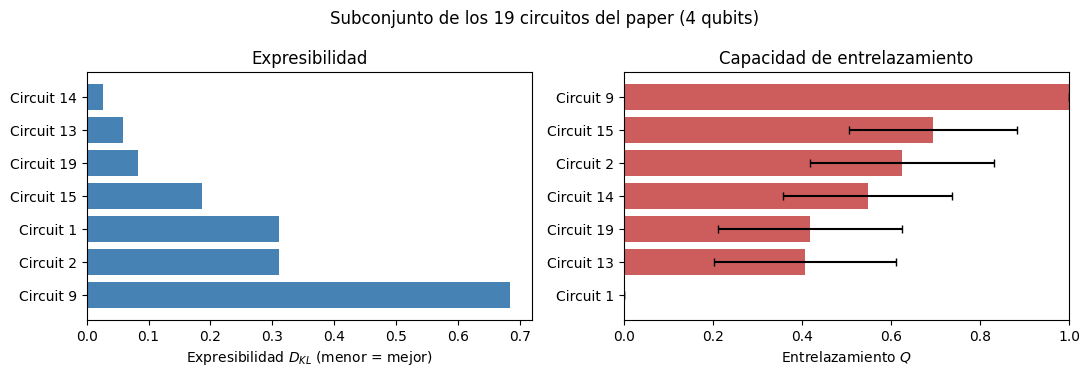

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
d1 = dfp.sort_values('expressibility_kl')
ax1.barh(d1['circuit'], d1['expressibility_kl'], color='steelblue')
ax1.set_xlabel('Expresibilidad $D_{KL}$ (menor = mejor)')
ax1.invert_yaxis()
ax1.set_title('Expresibilidad')
d2 = dfp.sort_values('entangling_Q', ascending=False)
ax2.barh(d2['circuit'], d2['entangling_Q'], xerr=d2['entangling_Q_std'],
         color='indianred', capsize=3)
ax2.set_xlim(0, 1)
ax2.set_xlabel('Entrelazamiento $Q$')
ax2.invert_yaxis()
ax2.set_title('Capacidad de entrelazamiento')
fig.suptitle('Subconjunto de los 19 circuitos del paper (4 qubits)')
fig.tight_layout()
qx.savefig(fig, os.path.join(FIGURES_DIR, 'E6_paper_reference.png'))
plt.show()

## Validación cualitativa frente al paper

Comprobamos los hallazgos publicados (no valores exactos, que dependen de muestreo/profundidad, sino el **ranking**).

In [12]:
byidx = {r['idx']: r for r in rows}
rank14 = sorted(byidx, key=lambda i: byidx[i]['expressibility_kl']).index(14) + 1
checks = {
    'Circuit 1 no entrelaza (Q ~ 0)': byidx[1]['entangling_Q'] < 0.05,
    'CRX (14) entrelaza >= CRZ (13)': byidx[14]['entangling_Q'] >= byidx[13]['entangling_Q'] - 0.02,
    'CRX (14) mas expresivo que CRZ (13)': byidx[14]['expressibility_kl'] <= byidx[13]['expressibility_kl'] + 0.02,
    'CRX (14) entre los 3 mas expresivos': rank14 <= 3,
}
for name, ok in checks.items():
    print(('[OK]  ' if ok else '[!!]  ') + name)
print('\nResumen:', sum(checks.values()), '/', len(checks), 'comprobaciones superadas')
print('\nNota: el Circuit 9 (H+CZ+RX, solo n parámetros) ilustra alta Q con baja '
      'expresibilidad: pocos parámetros limitan la expresibilidad pese a entrelazar mucho.')

[OK]  Circuit 1 no entrelaza (Q ~ 0)
[OK]  CRX (14) entrelaza >= CRZ (13)
[OK]  CRX (14) mas expresivo que CRZ (13)
[OK]  CRX (14) entre los 3 mas expresivos

Resumen: 4 / 4 comprobaciones superadas

Nota: el Circuit 9 (H+CZ+RX, solo n parámetros) ilustra alta Q con baja expresibilidad: pocos parámetros limitan la expresibilidad pese a entrelazar mucho.


Si todas las comprobaciones pasan, la implementación de `qexpr.py` reproduce el comportamiento cualitativo del paper y podemos confiar en las métricas del notebook 01.

Artefactos: `E6_paper_reference.csv`, `E6_paper_reference.png` en `TFM-EXPERIMENTS/outputs/`.